In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

In [ ]:
df=pd.read_csv('Healthcare-Diabetes.csv')
df.dropna(inplace=True)

# Drop duplicates
df.drop_duplicates(inplace=True)

# Display cleaned dataset
print(df.info())
print(df.shape)
print(df.describe())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2768 entries, 0 to 2767
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Id                        2768 non-null   int64  
 1   Pregnancies               2768 non-null   int64  
 2   Glucose                   2768 non-null   int64  
 3   BloodPressure             2768 non-null   int64  
 4   SkinThickness             2768 non-null   int64  
 5   Insulin                   2768 non-null   int64  
 6   BMI                       2768 non-null   float64
 7   DiabetesPedigreeFunction  2768 non-null   float64
 8   Age                       2768 non-null   int64  
 9   Outcome                   2768 non-null   int64  
dtypes: float64(2), int64(8)
memory usage: 216.4 KB
None
(2768, 10)
                Id  Pregnancies      Glucose  BloodPressure  SkinThickness  \
count  2768.000000  2768.000000  2768.000000    2768.000000    2768.000000   
mean   13

Predicted Diabetes Risk: tensor([-0.3255, -0.7070, -0.4941, -0.2858, -0.7464, -0.6299, -0.3854, -0.4334,
        -0.2669, -0.2117, -0.3160, -0.5050, -0.7302, -0.2858, -0.2637, -0.3255,
        -0.4670, -0.3561, -0.2637, -0.3097, -0.3614, -0.2116, -0.7724, -0.4276,
        -0.9298, -0.7400, -0.2943, -0.3763, -0.4670, -0.4528, -0.6085, -0.6021,
        -0.2865, -0.5414, -0.5504, -0.4400, -0.5186, -0.4480, -0.7070, -0.5257,
        -0.3806, -0.3763, -0.3520, -0.5308, -0.3833, -0.4993, -0.4065, -0.6013,
        -0.3035, -0.4960])


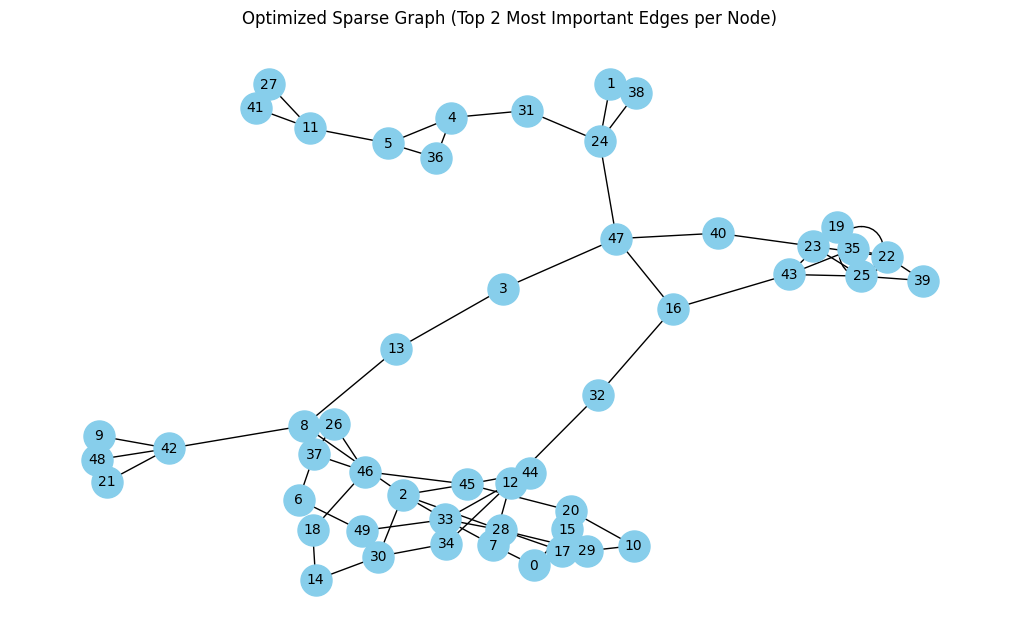

In [ ]:
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity

# Load dataset
df = pd.read_csv("Healthcare-Diabetes.csv")

# Drop 'Id' column
df.drop(columns=['Id'], inplace=True)

# Normalize numerical features
scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(df.drop(columns=['Outcome']))

# Convert to tensors
x = torch.tensor(scaled_features, dtype=torch.float)
y = torch.tensor(df['Outcome'].values, dtype=torch.float)

# Select a random sample of 50 for graph processing
num_samples = 50
sample_indices = np.random.choice(len(df), num_samples, replace=False)
sample_data = Data(x=x[sample_indices], y=y[sample_indices])

# Compute similarity matrix
similarity_matrix = cosine_similarity(sample_data.x.numpy())

# Keep only **top 2 strongest connections** per node
top_k = 2  # Adjust to control sparsity
edge_list = []

for i in range(num_samples):
    # Get indices of top-k most similar nodes (excluding self-loop)
    top_indices = np.argsort(similarity_matrix[i])[-(top_k + 1):-1]
    for j in top_indices:
        edge_list.append((i, j))

# Convert edge list to tensor
edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()
sample_data.edge_index = edge_index

# Define GCN model
class GCN(torch.nn.Module):
    def __init__(self):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(sample_data.x.shape[1], 16)
        self.conv2 = GCNConv(16, 1)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index)
        return x

# Train the model
model = GCN()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

model.train()
optimizer.zero_grad()
out = model(sample_data)
loss = F.mse_loss(out, sample_data.y.view(-1, 1))
loss.backward()
optimizer.step()

# Evaluate the model
model.eval()
with torch.no_grad():
    pred = model(sample_data)

print("Predicted Diabetes Risk:", pred.flatten())

# Visualize the reduced graph
G = nx.Graph()
G.add_edges_from(edge_index.t().tolist())

plt.figure(figsize=(10, 6))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color='skyblue', node_size=500, edge_color='k', linewidths=1, font_size=10)
plt.title("Optimized Sparse Graph (Top 2 Most Important Edges per Node)")
plt.show()


In [ ]:
pip install torch_geometric


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 19.0 MB/s eta 0:00:00


In [ ]:
# Print number of nodes and edges in the PyTorch Geometric graph
num_nodes = sample_data.x.shape[0]  # Number of nodes
num_edges = sample_data.edge_index.shape[1]  # Number of edges

print("Number of nodes:", num_nodes)
print("Number of edges:", num_edges)


Number of nodes: 50
Number of edges: 2450


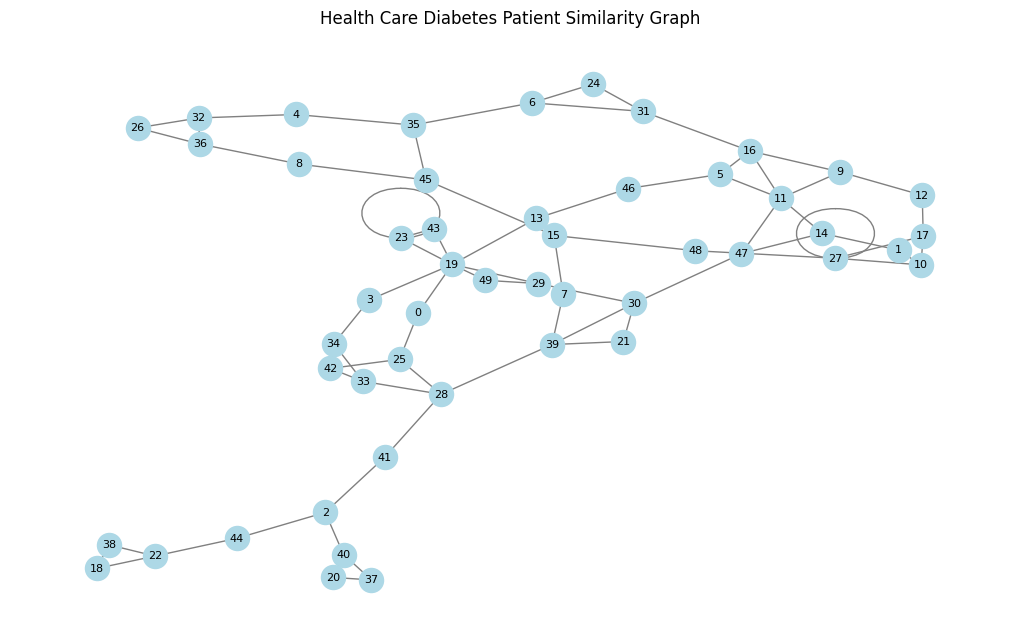

In [ ]:
import matplotlib.pyplot as plt

# Draw the graph
plt.figure(figsize=(10, 6))
nx.draw(G, with_labels=True, node_color='lightblue', edge_color='gray', font_size=8)
plt.title("Health Care Diabetes Patient Similarity Graph")
plt.show()


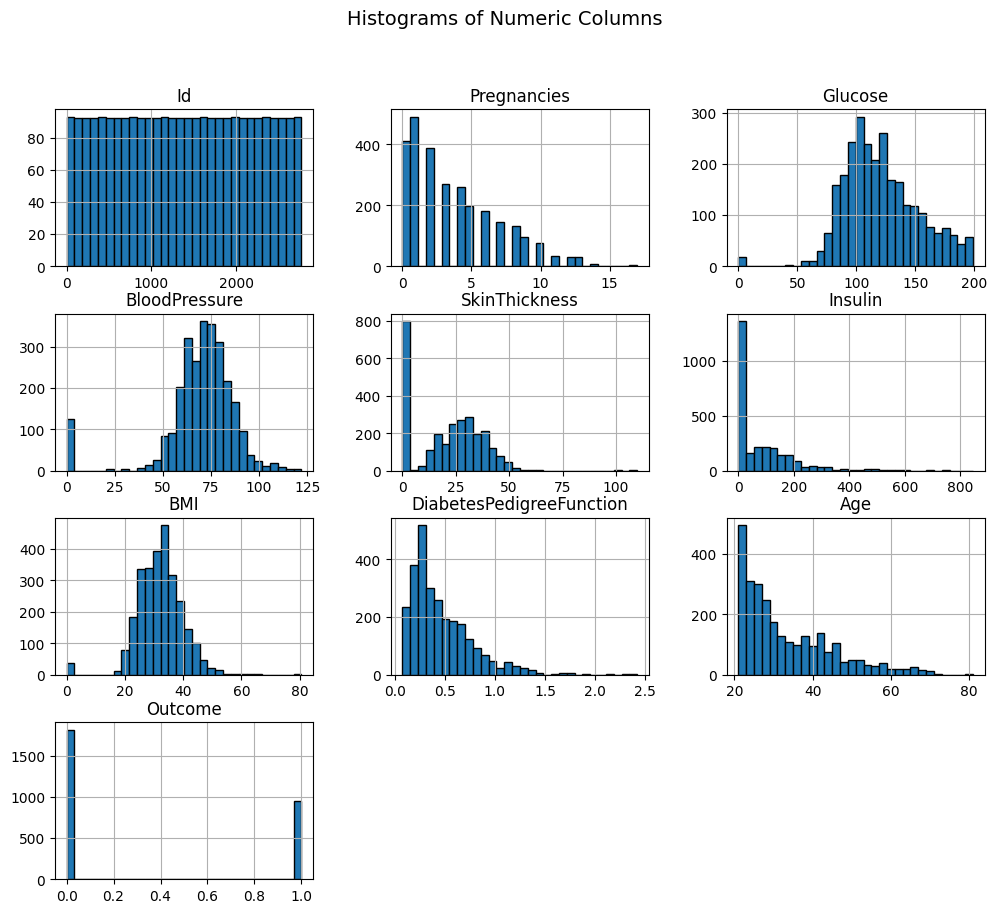

In [ ]:
# Select numeric columns
numeric_cols = df.select_dtypes(include=['number'])

# Plot histograms
numeric_cols.hist(figsize=(12, 10), bins=30, edgecolor='black')
plt.suptitle("Histograms of Numeric Columns", fontsize=14)
plt.show()


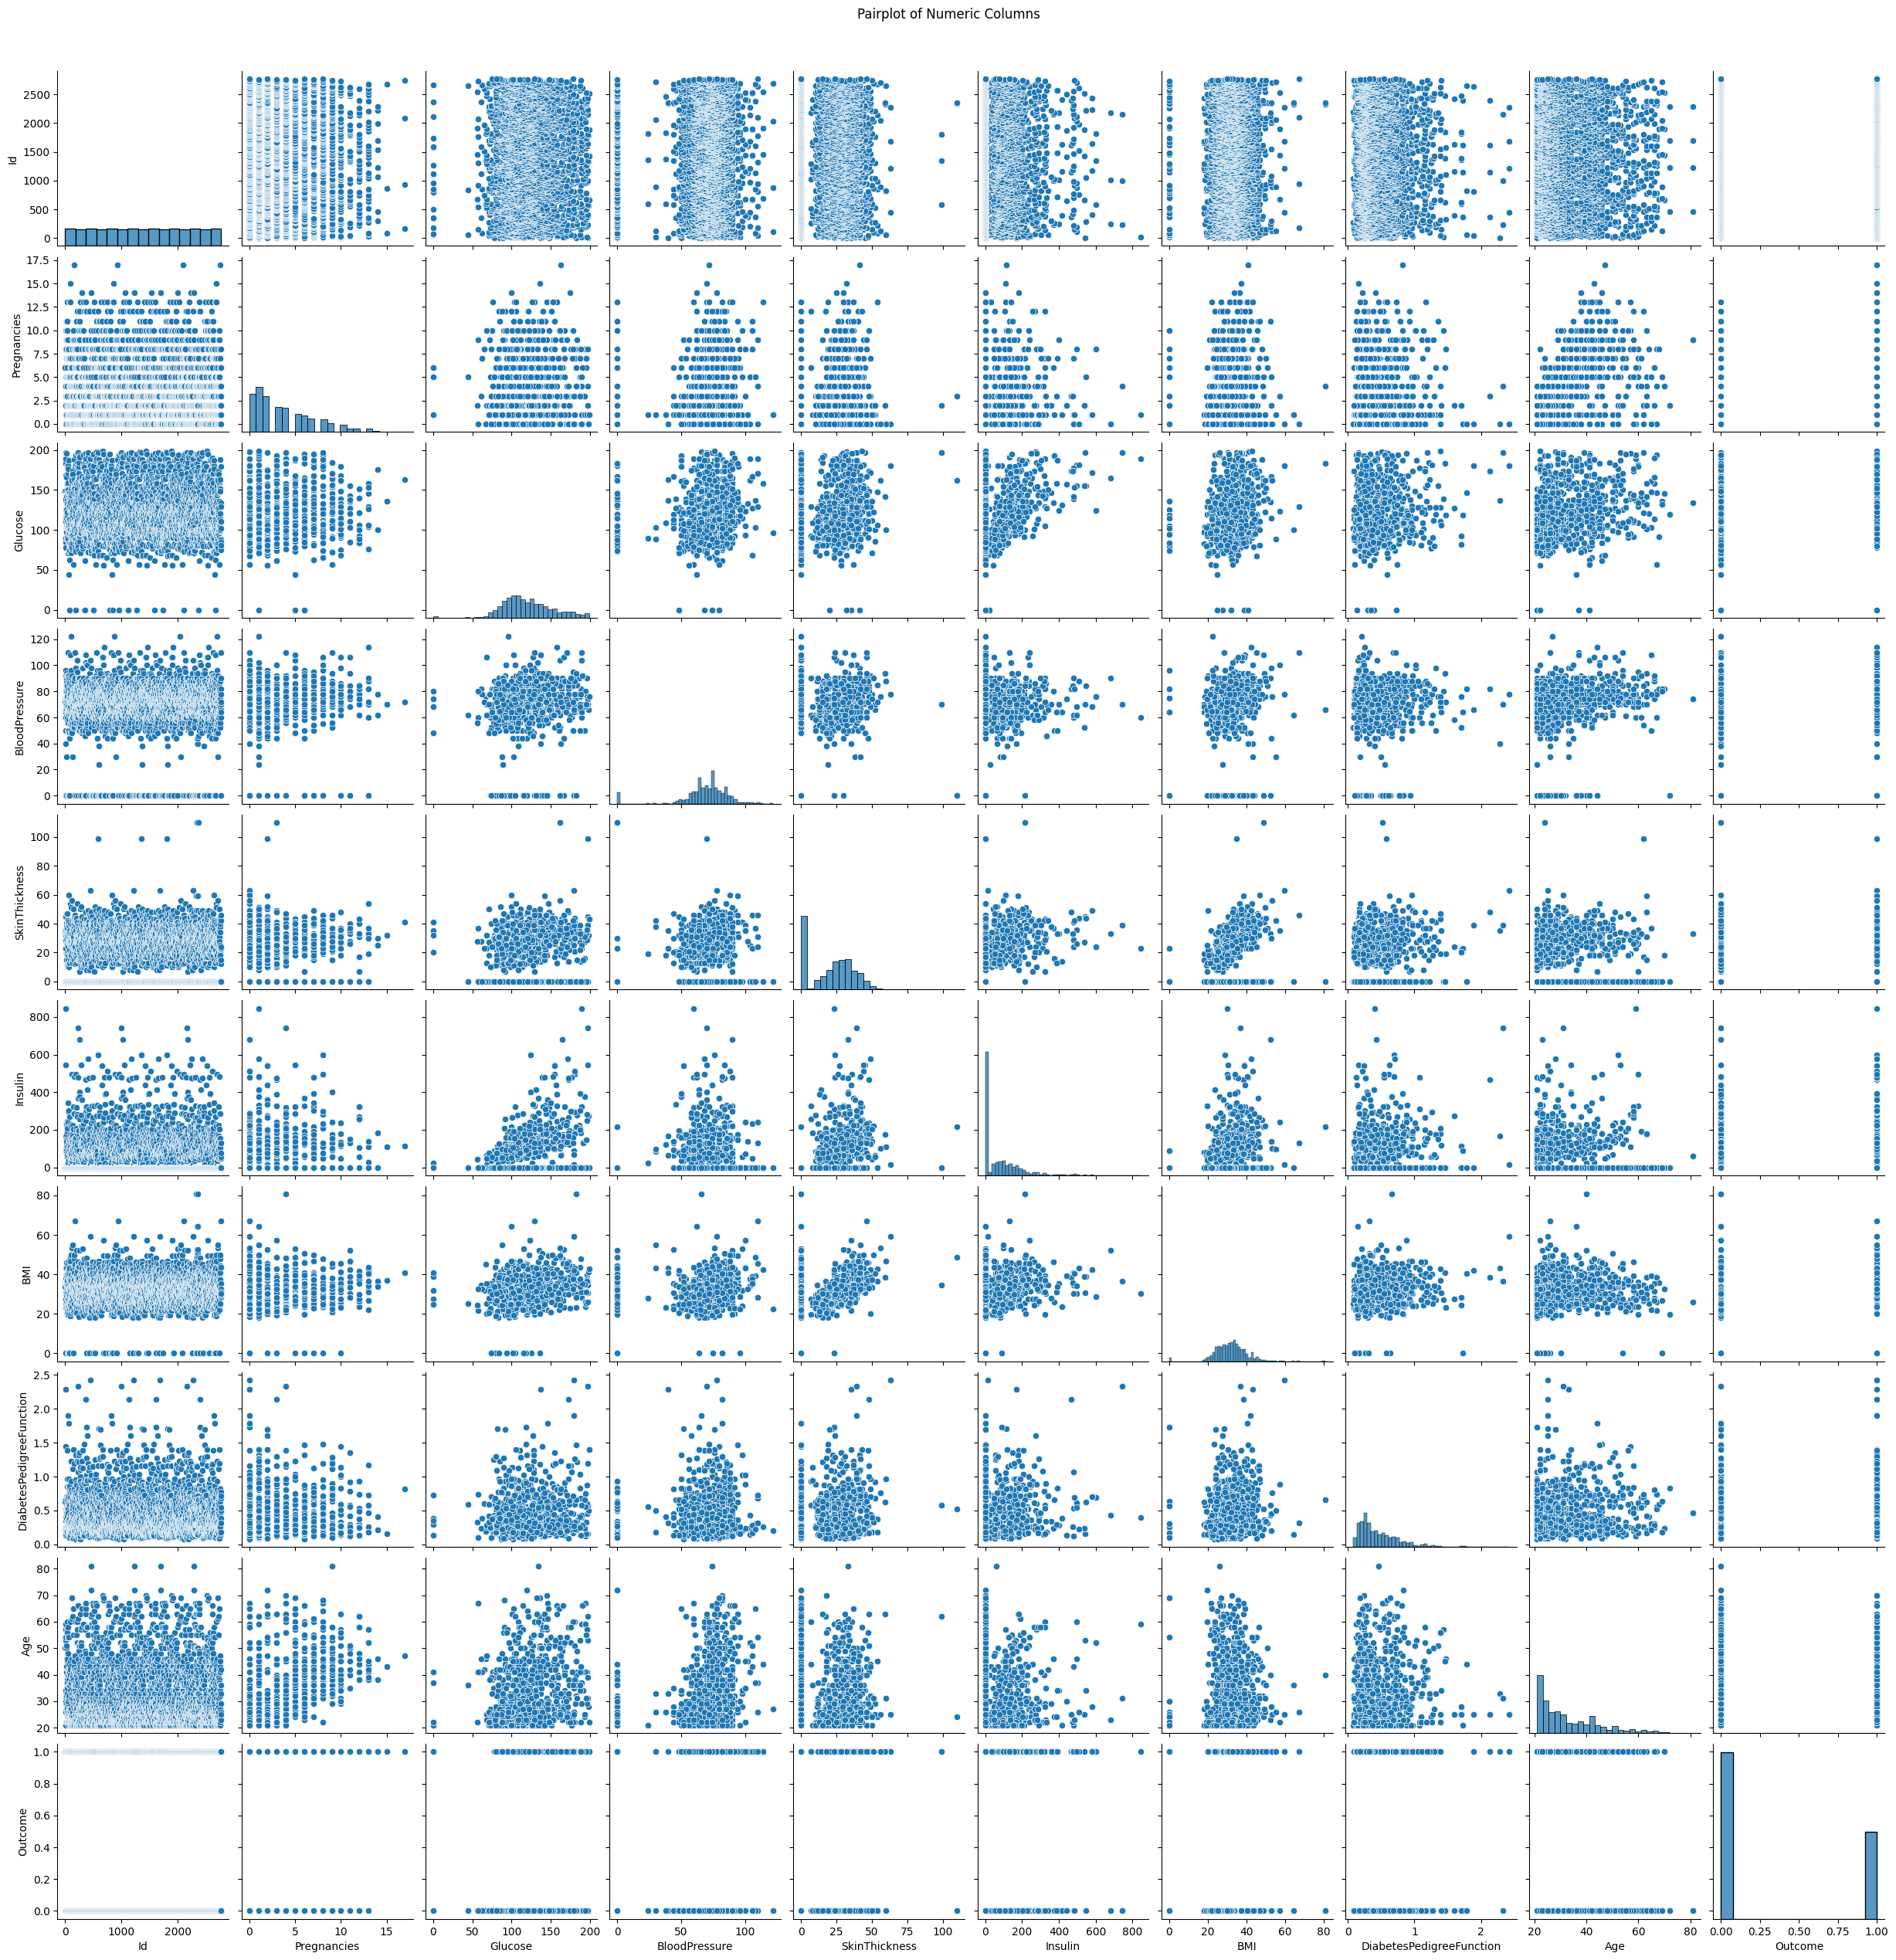

In [ ]:
import warnings
warnings.filterwarnings("ignore")  # Suppress warnings for large plots

# Pairplot for numeric columns
sns.pairplot(numeric_cols)
plt.suptitle("Pairplot of Numeric Columns", y=1.02)
plt.show()


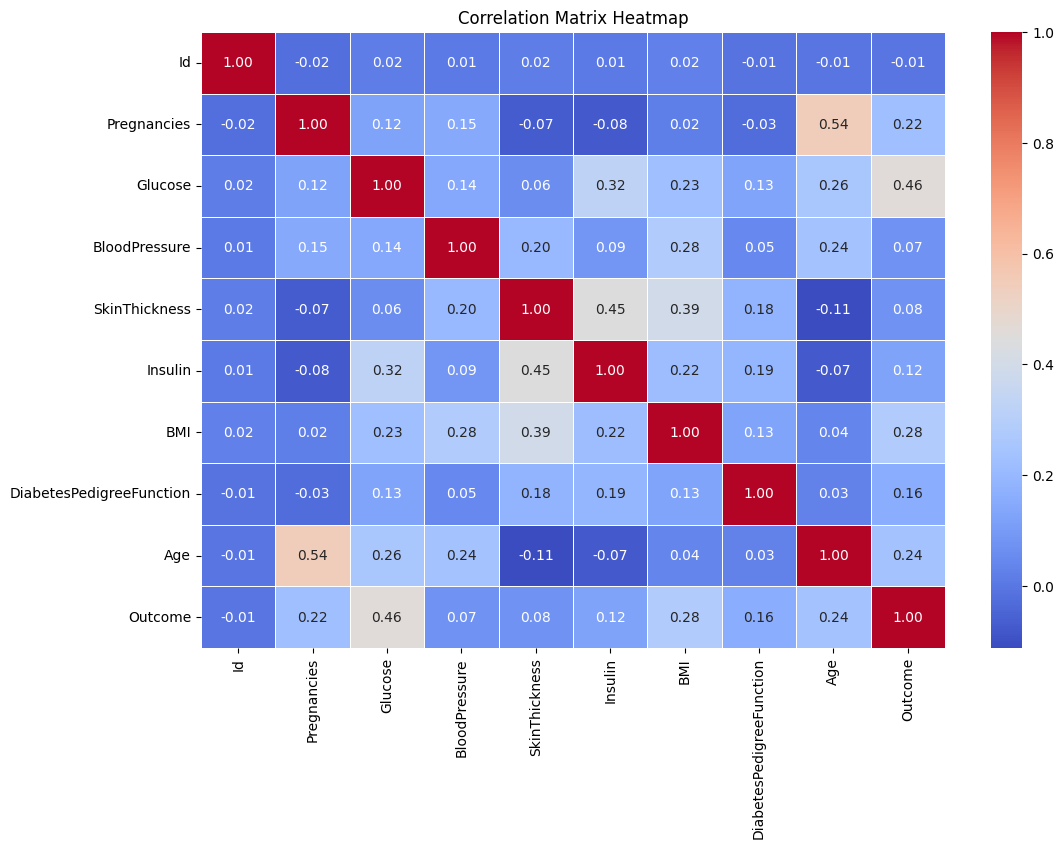

In [ ]:
import numpy as np

# Compute correlation matrix
corr_matrix = numeric_cols.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix Heatmap")
plt.show()


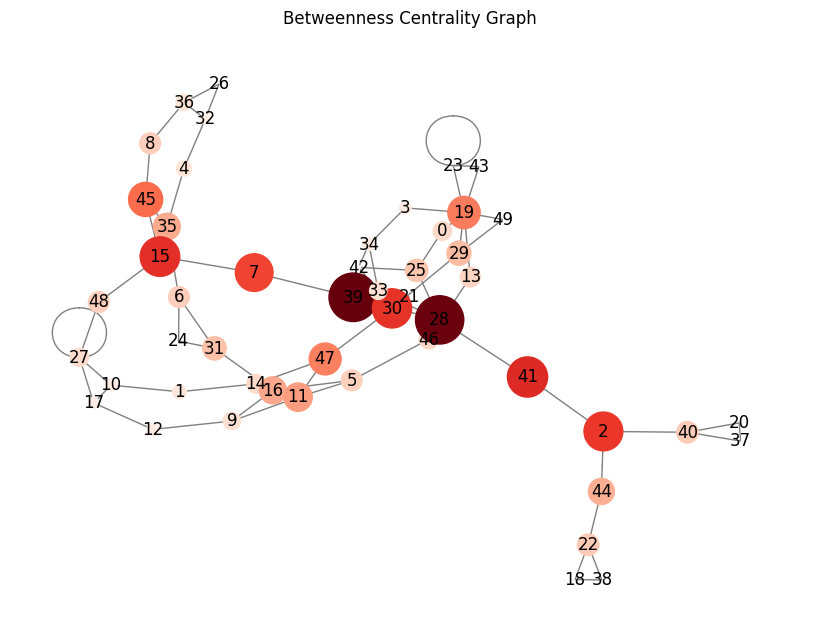

In [ ]:
plt.figure(figsize=(8, 6))
betweenness_centrality = nx.betweenness_centrality(G)
nx.draw(G, with_labels=True, node_size=[v * 3000 for v in betweenness_centrality.values()],
        node_color=list(betweenness_centrality.values()), cmap=plt.cm.Reds, edge_color="gray")
plt.title("Betweenness Centrality Graph")
plt.show()


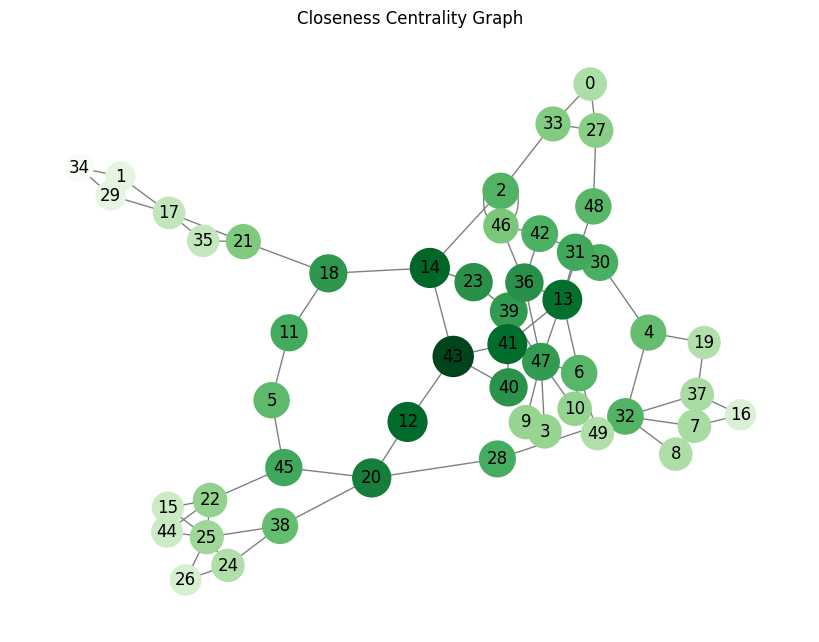

In [ ]:
plt.figure(figsize=(8, 6))
closeness_centrality = nx.closeness_centrality(G)
nx.draw(G, with_labels=True, node_size=[v * 3000 for v in closeness_centrality.values()],
        node_color=list(closeness_centrality.values()), cmap=plt.cm.Greens, edge_color="gray")
plt.title("Closeness Centrality Graph")
plt.show()


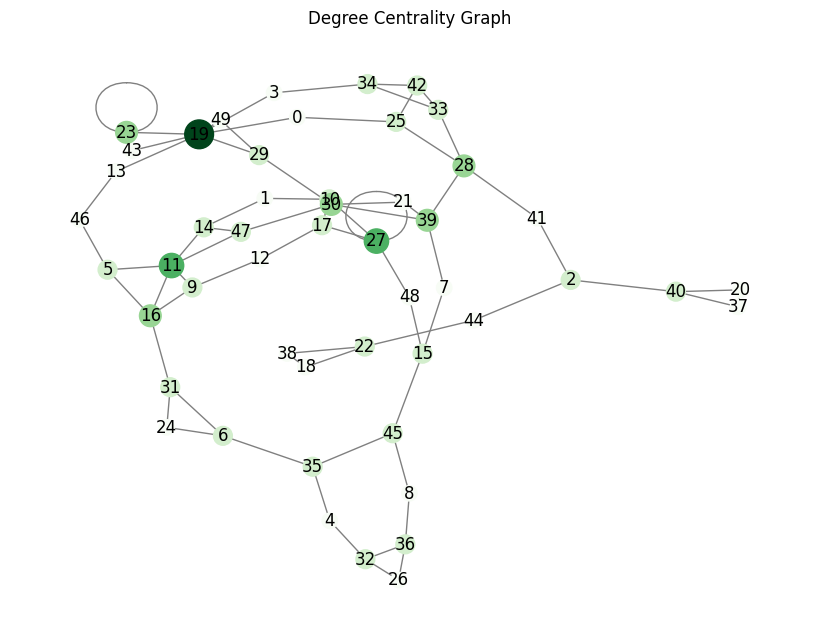

In [ ]:
plt.figure(figsize=(8, 6))
degree_centrality = nx.degree_centrality(G)
nx.draw(G, with_labels=True, node_size=[v * 3000 for v in degree_centrality.values()],
        node_color=list(degree_centrality.values()), cmap=plt.cm.Greens, edge_color="gray")
plt.title("Degree Centrality Graph")
plt.show()


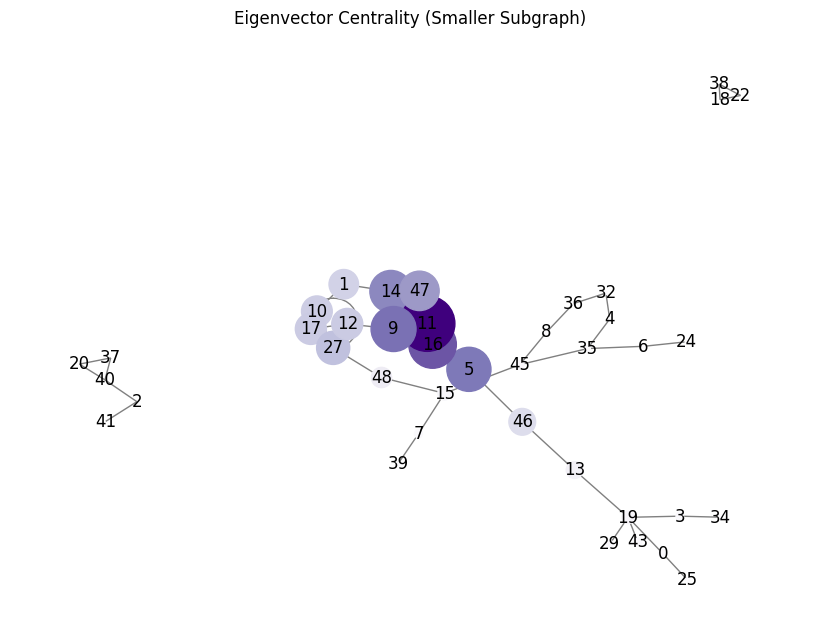

In [ ]:
subgraph_nodes = list(G.nodes)[:40]  # Take only first 20 nodes
G_sub = G.subgraph(subgraph_nodes)

try:
    eigenvector_centrality = nx.eigenvector_centrality(G_sub)
    plt.figure(figsize=(8, 6))
    nx.draw(G_sub, with_labels=True, node_size=[v * 3000 for v in eigenvector_centrality.values()],
            node_color=list(eigenvector_centrality.values()), cmap=plt.cm.Purples, edge_color="gray")
    plt.title("Eigenvector Centrality (Smaller Subgraph)")
    plt.show()
except nx.PowerIterationFailedConvergence:
    print("Eigenvector centrality did not converge on the smaller subgraph either.")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2768 entries, 0 to 2767
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Id                        2768 non-null   int64  
 1   Pregnancies               2768 non-null   int64  
 2   Glucose                   2768 non-null   int64  
 3   BloodPressure             2768 non-null   int64  
 4   SkinThickness             2768 non-null   int64  
 5   Insulin                   2768 non-null   int64  
 6   BMI                       2768 non-null   float64
 7   DiabetesPedigreeFunction  2768 non-null   float64
 8   Age                       2768 non-null   int64  
 9   Outcome                   2768 non-null   int64  
dtypes: float64(2), int64(8)
memory usage: 216.4 KB
None
   Id  Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0   1            6      148             72             35        0  33.6   
1   2            1      

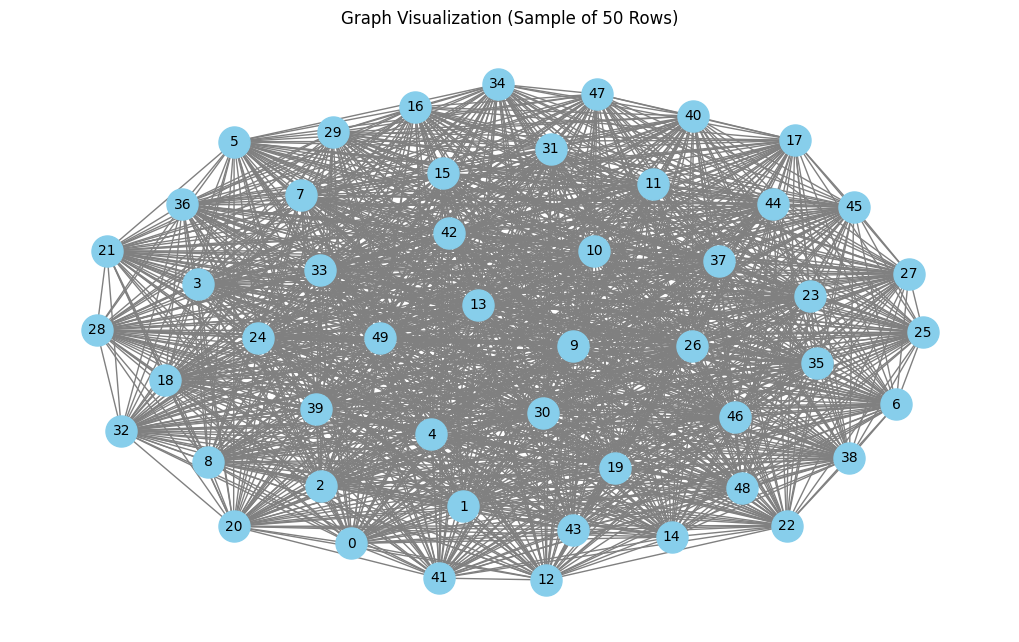

In [ ]:
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
import pandas as pd
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import networkx as nx
import matplotlib.pyplot as plt
import random

# Load the dataset
file_path = "Healthcare-Diabetes.csv"
df = pd.read_csv(file_path)

# Display dataset info
print(df.info())
print(df.head())

# Encoding categorical variables (if any exist)
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

# Normalizing numerical features
scaler = MinMaxScaler()
numeric_features = df.select_dtypes(include=['number'])
scaled_features = scaler.fit_transform(numeric_features)

# Convert to PyTorch tensors
x = torch.tensor(scaled_features, dtype=torch.float)
y = torch.tensor(df['Outcome'].values, dtype=torch.float)  # Assuming 'Diabetes' is the target column

# Randomly select 50 samples
sample_indices = random.sample(range(len(df)), 50)
sample_data = Data(x=x[sample_indices], y=y[sample_indices])

# Create edges using a fully connected approach
num_nodes = len(sample_data.x)
edge_index = torch.tensor([(i, j) for i in range(num_nodes) for j in range(num_nodes) if i != j], dtype=torch.long).t().contiguous()

# Assign edges to data
sample_data.edge_index = edge_index

# Define Graph Convolutional Network (GCN)
class GCN(torch.nn.Module):
    def __init__(self, in_channels):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(in_channels, 16)
        self.conv2 = GCNConv(16, 1)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index)
        return x

# Initialize model
model = GCN(in_channels=x.shape[1])
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Train the GCN model
model.train()
optimizer.zero_grad()
out = model(sample_data)
loss = F.mse_loss(out, sample_data.y.view(-1, 1))
loss.backward()
optimizer.step()

# Evaluate model
model.eval()
with torch.no_grad():
    pred = model(sample_data)

print("Predicted Diabetes Risk Scores:", pred.flatten())

# Convert edges for visualization
edges = edge_index.t().tolist()
G = nx.Graph()
G.add_edges_from(edges)

# Graph Visualization
plt.figure(figsize=(10, 6))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color='skyblue', node_size=500, edge_color='gray', linewidths=1, font_size=10)
plt.title("Graph Visualization (Sample of 50 Rows)")
plt.show()


Predicted Diabetes Risk Scores: tensor([-0.0923, -0.0923, -0.0923, -0.0923, -0.0923, -0.0923, -0.0923, -0.0923,
        -0.0923, -0.0923, -0.0923, -0.0923, -0.0923, -0.0923, -0.0923, -0.0923,
        -0.0923, -0.0923, -0.0923, -0.0923, -0.0923, -0.0923, -0.0923, -0.0923,
        -0.0923, -0.0923, -0.0923, -0.0923, -0.0923, -0.0923, -0.0923, -0.0923,
        -0.0923, -0.0923, -0.0923, -0.0923, -0.0923, -0.0923, -0.0923, -0.0923,
        -0.0923, -0.0923, -0.0923, -0.0923, -0.0923, -0.0923, -0.0923, -0.0923,
        -0.0923, -0.0923])


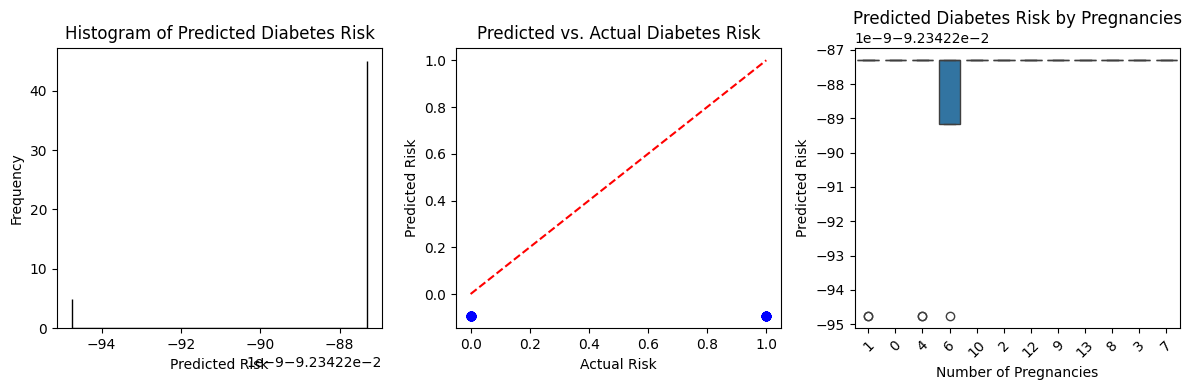

In [ ]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import random
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
import torch.nn.functional as F

# Load dataset
file_path = "Healthcare-Diabetes.csv"
df = pd.read_csv(file_path)

# Normalize numerical features
scaler = MinMaxScaler()
numeric_features = df.select_dtypes(include=['number'])
scaled_features = scaler.fit_transform(numeric_features)

# Convert to PyTorch tensors
x = torch.tensor(scaled_features, dtype=torch.float)
y = torch.tensor(df['Outcome'].values, dtype=torch.float)  # Assuming 'Outcome' is the target

# Select 50 random samples
sample_indices = random.sample(range(len(df)), 50)
sample_data = Data(x=x[sample_indices], y=y[sample_indices])

# Fully connected graph for sample data
num_nodes = len(sample_data.x)
edge_index = torch.tensor([(i, j) for i in range(num_nodes) for j in range(num_nodes) if i != j], dtype=torch.long).t().contiguous()
sample_data.edge_index = edge_index

# Define Graph Neural Network (GCN)
class GCN(torch.nn.Module):
    def __init__(self, in_channels):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(in_channels, 16)
        self.conv2 = GCNConv(16, 1)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index)
        return x

# Train GCN model
model = GCN(in_channels=x.shape[1])
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

model.train()
optimizer.zero_grad()
out = model(sample_data)
loss = F.mse_loss(out, sample_data.y.view(-1, 1))
loss.backward()
optimizer.step()

# Predict Diabetes Risk
model.eval()
with torch.no_grad():
    pred = model(sample_data)

print("Predicted Diabetes Risk Scores:", pred.flatten())

# ------------------- PLOTTING -------------------
plt.figure(figsize=(12, 4))

# Histogram of Predicted Diabetes Risk
plt.subplot(1, 3, 1)
plt.hist(pred.flatten(), bins=20, color='skyblue', edgecolor='black')
plt.title('Histogram of Predicted Diabetes Risk')
plt.xlabel('Predicted Risk')
plt.ylabel('Frequency')

# Scatter Plot: Predicted vs Actual Diabetes Risk
plt.subplot(1, 3, 2)
plt.scatter(sample_data.y.flatten(), pred.flatten(), color='blue')
plt.plot([sample_data.y.min(), sample_data.y.max()], [sample_data.y.min(), sample_data.y.max()], linestyle='--', color='red')
plt.title('Predicted vs. Actual Diabetes Risk')
plt.xlabel('Actual Risk')
plt.ylabel('Predicted Risk')

# Box Plot: Predicted Diabetes Risk by Pregnancies
plt.subplot(1, 3, 3)
df_sample = df.iloc[sample_indices].copy()
df_sample['Predicted Risk'] = pred.flatten()

# Convert Pregnancies to a categorical variable for plotting
df_sample['Pregnancies'] = df_sample['Pregnancies'].astype(str)

ax = sns.boxplot(x='Pregnancies', y='Predicted Risk', data=df_sample)
plt.title('Predicted Diabetes Risk by Pregnancies')
plt.xlabel('Number of Pregnancies')
plt.ylabel('Predicted Risk')
plt.xticks(rotation=45)  # Rotate x-axis labels if needed

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Load dataset
file_path = "Healthcare-Diabetes.csv"
df = pd.read_csv(file_path)

# Normalize numerical features
scaler = MinMaxScaler()
numeric_features = df.select_dtypes(include=['number']).columns.drop('Outcome')
df[numeric_features] = scaler.fit_transform(df[numeric_features])

# Define features and target variable
X = df[numeric_features]
y = df['Outcome']

# Handle class imbalance using SMOTE
smote = SMOTE(random_state=42)
X, y = smote.fit_resample(X, y)

# Split dataset into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Optimized Random Forest Classifier
rf = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_split=5, min_samples_leaf=2, random_state=42)
rf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf.predict(X_test)

# Print model performance
print("Optimized Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Classification Report (RF):\n", classification_report(y_test, y_pred_rf))

# Train XGBoost Classifier (alternative for better accuracy)
xgb = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1)
xgb.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb.predict(X_test)

# Print model performance
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Classification Report (XGB):\n", classification_report(y_test, y_pred_xgb))

lgbm = LGBMClassifier(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42)
lgbm.fit(X_train, y_train)

# Predictions
y_pred_lgbm = lgbm.predict(X_test)

# Print model performance
print("LightGBM Accuracy:", accuracy_score(y_test, y_pred_lgbm))
print("Classification Report:\n", classification_report(y_test, y_pred_lgbm))

# Get feature importances
feature_importances = rf.feature_importances_
features = X.columns

# Sort features by importance
sorted_indices = np.argsort(feature_importances)[::-1]
sorted_features = [features[i] for i in sorted_indices]
sorted_importances = feature_importances[sorted_indices]


Optimized Random Forest Accuracy: 0.9504814305364512
Classification Report (RF):
               precision    recall  f1-score   support

           0       0.97      0.93      0.95       377
           1       0.93      0.97      0.95       350

    accuracy                           0.95       727
   macro avg       0.95      0.95      0.95       727
weighted avg       0.95      0.95      0.95       727

XGBoost Accuracy: 0.9752407152682255
Classification Report (XGB):
               precision    recall  f1-score   support

           0       0.98      0.97      0.98       377
           1       0.97      0.98      0.97       350

    accuracy                           0.98       727
   macro avg       0.98      0.98      0.98       727
weighted avg       0.98      0.98      0.98       727

[LightGBM] [Info] Number of positive: 1466, number of negative: 1439
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000580 seconds.
You can set `force_col_w

<ipython-input-5-a7564267ed1f>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_importances, y=sorted_features, palette="viridis")


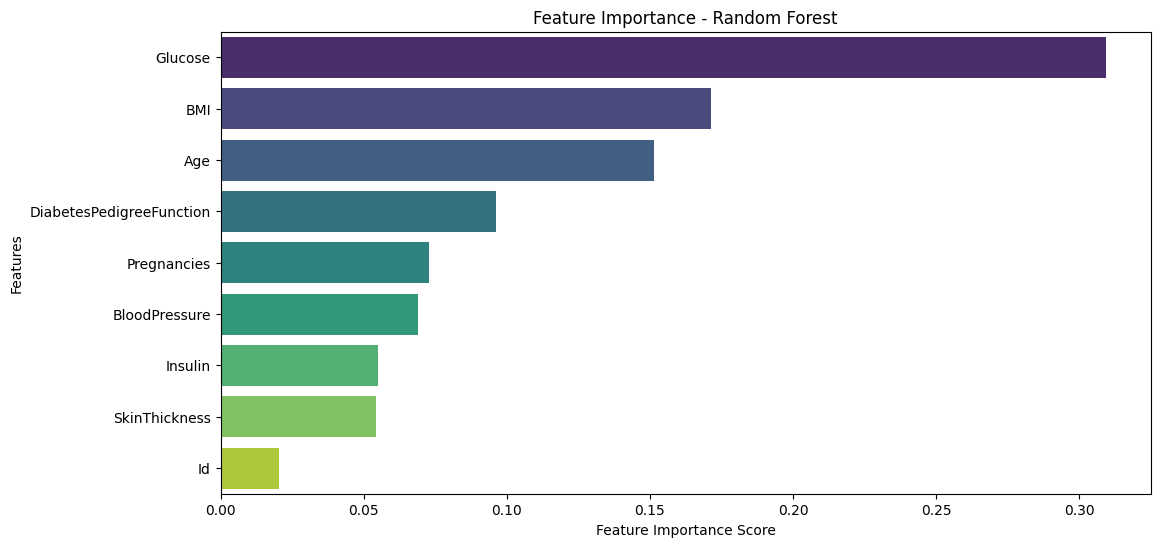

<ipython-input-5-a7564267ed1f>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_importances, y=sorted_features, palette="viridis")


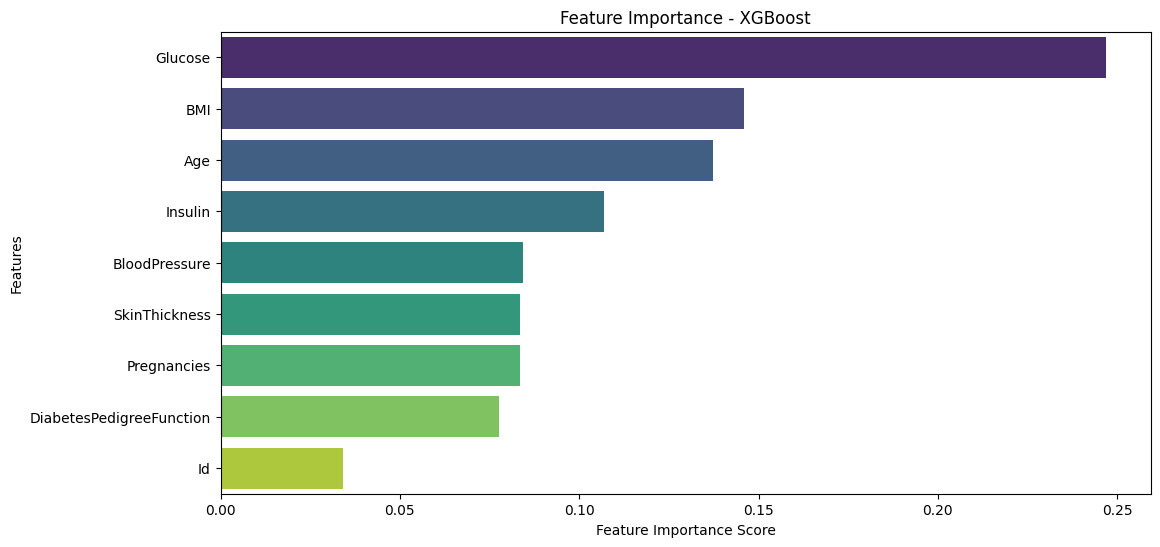

<ipython-input-5-a7564267ed1f>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_importances, y=sorted_features, palette="viridis")


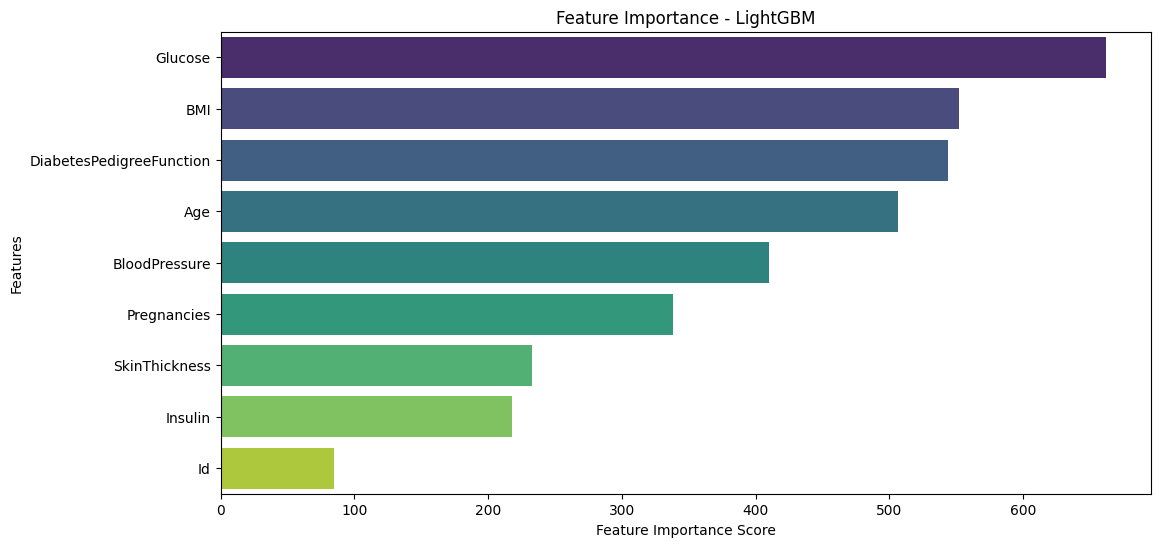

<ipython-input-5-a7564267ed1f>:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=accuracies, palette='coolwarm')


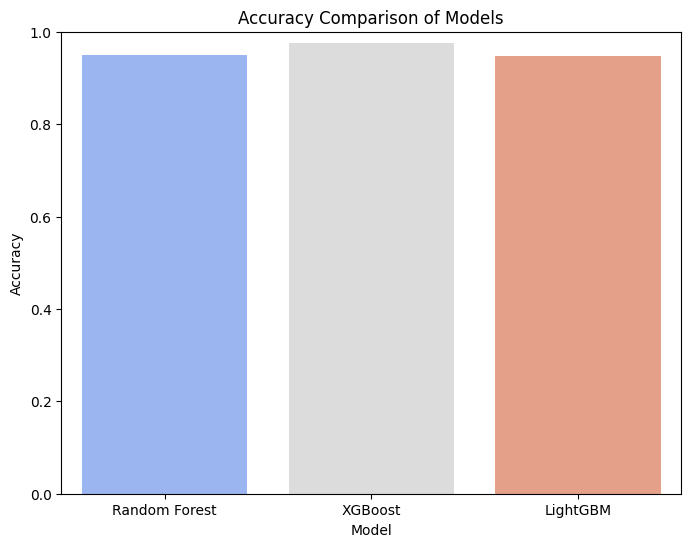

In [ ]:
# Function to plot feature importance
def plot_feature_importance(model, X, title):
    feature_importances = model.feature_importances_
    features = X.columns
    sorted_indices = np.argsort(feature_importances)[::-1]
    sorted_features = [features[i] for i in sorted_indices]
    sorted_importances = feature_importances[sorted_indices]

    plt.figure(figsize=(12, 6))
    sns.barplot(x=sorted_importances, y=sorted_features, palette="viridis")
    plt.xlabel("Feature Importance Score")
    plt.ylabel("Features")
    plt.title(f"Feature Importance - {title}")
    plt.show()

# Plot feature importance for each model
plot_feature_importance(rf, X, "Random Forest")
plot_feature_importance(xgb, X, "XGBoost")
plot_feature_importance(lgbm, X, "LightGBM")

# Plot model accuracy comparison
accuracies = [accuracy_score(y_test, y_pred_rf), accuracy_score(y_test, y_pred_xgb), accuracy_score(y_test, y_pred_lgbm)]
labels = ['Random Forest', 'XGBoost', 'LightGBM']
plt.figure(figsize=(8, 6))
sns.barplot(x=labels, y=accuracies, palette='coolwarm')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison of Models')
plt.ylim(0, 1)
plt.show()
